In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 87.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 72.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 78.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# =============================
# COMPLETE TRAINING PIPELINE
# =============================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_benign = np.load("X_train_scaled.npy")     # benign only
X_attack = np.load("X_attack_scaled.npy")    # attack (not used in training)

# Split
X_train_benign, X_test_benign = train_test_split(
    X_benign,
    test_size=0.2,
    random_state=42
)

np.save("X_test_benign.npy", X_test_benign)

# Create DataLoader

X_train_tensor = torch.tensor(X_train_benign, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=1024,
    shuffle=True
)

input_dim = X_train_benign.shape[1]

# autoenc
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


model = Autoencoder(input_dim).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Training

epochs = 50
patience = 5
best_loss = float("inf")
counter = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for batch in train_loader:
        data = batch[0].to(device)

        optimizer.zero_grad()
        recon = model(data)
        loss = criterion(recon, data)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.6f}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), "best_autoencoder.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

print("Training complete.")

Epoch 1, Loss: 0.049042
Epoch 2, Loss: 0.009039
Epoch 3, Loss: 0.006304
Epoch 4, Loss: 0.005134
Epoch 5, Loss: 0.004327
Epoch 6, Loss: 0.003771
Epoch 7, Loss: 0.003396
Epoch 8, Loss: 0.003179
Epoch 9, Loss: 0.002971
Epoch 10, Loss: 0.002856
Epoch 11, Loss: 0.002653
Epoch 12, Loss: 0.002520
Epoch 13, Loss: 0.002445
Epoch 14, Loss: 0.002327
Epoch 15, Loss: 0.002267
Epoch 16, Loss: 0.002201
Epoch 17, Loss: 0.002148
Epoch 18, Loss: 0.002019
Epoch 19, Loss: 0.002089
Epoch 20, Loss: 0.001944
Epoch 21, Loss: 0.001956
Epoch 22, Loss: 0.001910
Epoch 23, Loss: 0.001882
Epoch 24, Loss: 0.001849
Epoch 25, Loss: 0.001819
Epoch 26, Loss: 0.001766
Epoch 27, Loss: 0.001767
Epoch 28, Loss: 0.001735
Epoch 29, Loss: 0.001739
Epoch 30, Loss: 0.001704
Epoch 31, Loss: 0.001670
Epoch 32, Loss: 0.001678
Epoch 33, Loss: 0.001652
Epoch 34, Loss: 0.001579
Epoch 35, Loss: 0.001594
Epoch 36, Loss: 0.001595
Epoch 37, Loss: 0.001571
Epoch 38, Loss: 0.001591
Epoch 39, Loss: 0.001532
Epoch 40, Loss: 0.001521
Epoch 41,

In [ ]:

# TESTING / EVALUATION
import numpy as np
import torch
from sklearn.metrics import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_benign = np.load("X_train_scaled.npy")
X_test_benign = np.load("X_test_benign.npy")
X_attack = np.load("X_attack_scaled.npy")

input_dim = X_train_benign.shape[1]

model = Autoencoder(input_dim).to(device)
model.load_state_dict(torch.load("best_autoencoder.pth"))
model.eval()

def reconstruction_error(model, data_tensor):
    with torch.no_grad():
        recon = model(data_tensor)
        error = torch.mean((data_tensor - recon) ** 2, dim=1)
    return error.cpu().numpy()

train_tensor = torch.tensor(X_train_benign, dtype=torch.float32).to(device)
train_errors = reconstruction_error(model, train_tensor)

threshold = np.percentile(train_errors, 95)

test_benign_tensor = torch.tensor(X_test_benign, dtype=torch.float32).to(device)
attack_tensor = torch.tensor(X_attack, dtype=torch.float32).to(device)

test_benign_errors = reconstruction_error(model, test_benign_tensor)
attack_errors = reconstruction_error(model, attack_tensor)

y_test_benign = np.zeros(len(test_benign_errors))
y_attack = np.ones(len(attack_errors))

y_true = np.concatenate([y_test_benign, y_attack])
scores = np.concatenate([test_benign_errors, attack_errors])

y_pred = (scores > threshold).astype(int)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, scores)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print(f"Threshold: {threshold:.6f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"False Negative Rate: {fnr:.4f}")
print("\nConfusion Matrix:\n", cm)

Threshold: 0.002689
Accuracy: 0.9871
Precision: 0.9829
Recall: 1.0000
F1 Score: 0.9914
ROC-AUC: 0.9980
False Positive Rate: 0.0499
False Negative Rate: 0.0000

Confusion Matrix:
 [[126137   6625]
 [     0 380943]]


reconstruction error distribution

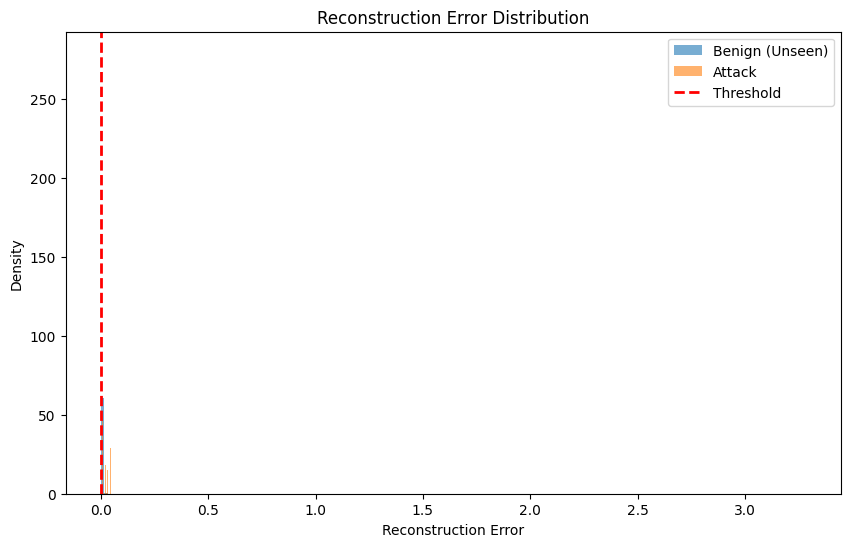

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(test_benign_errors, bins=200, alpha=0.6, density=True, label="Benign (Unseen)")
plt.hist(attack_errors, bins=200, alpha=0.6, density=True, label="Attack")

plt.axvline(threshold, color="red", linestyle="--", linewidth=2, label="Threshold")

plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.show()

ROC curve

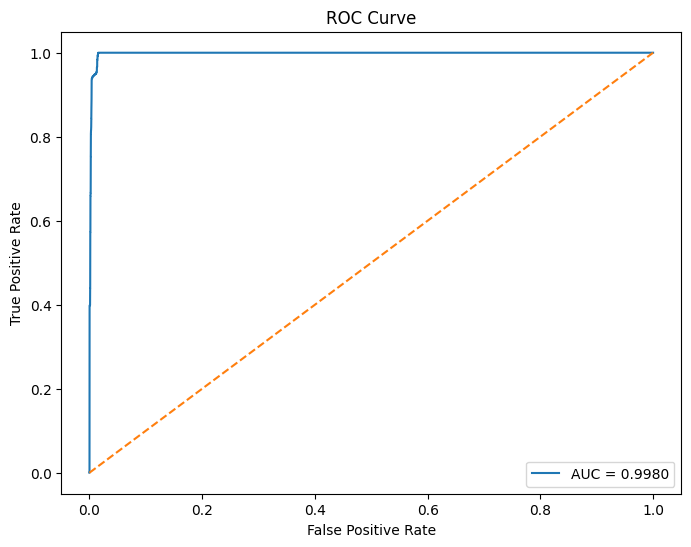

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_curve, tpr_curve, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr_curve, tpr_curve)

plt.figure(figsize=(8,6))
plt.plot(fpr_curve, tpr_curve, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

confusion matrix

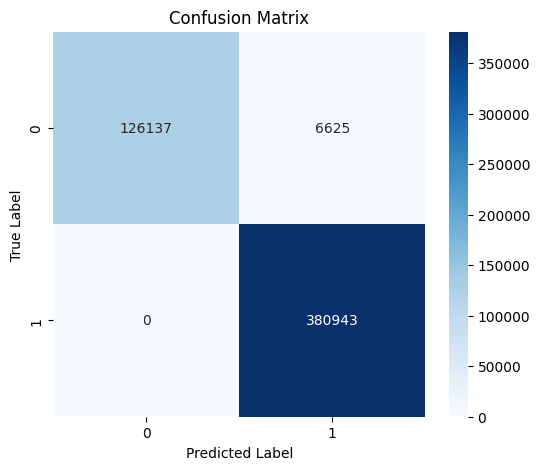

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()